# Wavelet Analysis: Theory and Application to African Easterly Waves

## 1. Introduction and Theory

### Limitations of Fourier analysis

In climate science, we frequently analyse time series data to find dominant cycles—such as the El Niño-Southern Oscillation (ENSO) or diurnal temperature variations. As we saw in the last lesson, Fourier analysis is the traditional tool for this, decomposing a signal into constituent sine and cosine waves to identify dominant frequencies.

However, the Fourier transform only allows us to find **stationary** signals, i.e. the resul is is an "average" measure of the power of each frequency over the entire timeseries.  In some cases, there may be a signal we want to detect which is *intermittent* and we are interested to know when variability of a certain timescale is occuring. 

For example, if we want to detect African Easterly Waves (AEWs)—synoptic disturbances that only occur during the West African Monsoon season—a standard Fourier transform will tell us a 3-5 day periodicity exists as a peak in the power sprectrum, but it cannot tell us *when* it occurs to highlight periods of high AEW activity. 

### Wavelet analysis

Wavelet overcomes this by using localized wave-like functions (wavelets). Instead of infinite cosine waves, wavelets decay to zero at their edges. By stretching (scaling) and shifting (translating) these wavelets across our time series, we build a two-dimensional picture of both frequency (scale) *and* time.

# The Continuous Wavelet Transform (CWT)

The CWT is essentially a **mathematical microscope**. Unlike the Fourier Transform, which tells you *what* frequencies exist in a signal, the CWT tells you **when** those frequencies occur and **how long** they last by sliding a "wavelet" along the data.  Unlike the Fourier Transform, which tells you *what* frequencies exist in a signal, the CWT tells you **when** those frequencies occur and **how long** they last by sliding a "wavelet" along the data.

## The Continuous Definition
At its core, the CWT measures the "similarity" between your signal $x(t)$ and a transformed version of a Mother Wavelet $\psi$.

$$W(s, \tau) = \int_{-\infty}^{\infty} x(t) \psi_{s, \tau}^*(t) dt$$

* **$x(t)$**: The input signal.
* **$W(s, \tau)$**: The resulting Wavelet Coefficients.
* **$\psi^*$**: The complex conjugate of the "Daughter Wavelet."


## 2. Scaling and Shifting (The "Daughter" Wavelet)
To analyze different frequencies and time positions, we take one single **Mother Wavelet** $\psi(t)$ and modify it using two parameters: **Scale ($s$)** and **Translation ($\tau$)**.

$$\psi_{s, \tau}(t) = \frac{1}{\sqrt{s}} \psi \left( \frac{t - \tau}{s} \right)$$

* **$\tau$ (Translation):** Slides the wavelet along the time axis to look at different parts of the signal.
* **$s$ (Scale):** Stretches or compresses the wavelet.
    * **Small $s$:** Compressed shape $\rightarrow$ captures **high-frequency** (fast) changes.
    * **Large $s$:** Stretched shape $\rightarrow$ captures **low-frequency** (slow) trends.
* **$1/\sqrt{s}$ (Normalization):** Ensures the wavelet has the same total energy at every scale so that high and low frequencies can be compared fairly.



## The Morlet Mother Wavelet
In many applications (like geophysics or bio-signals), we use the **Morlet Wavelet**. It is a complex sine wave multiplied by a Gaussian "envelope." 

$$\psi_0(\eta) = \pi^{-1/4} e^{i \omega_0 \eta} e^{-\eta^2 / 2}$$

### Key Components:
1. **$\pi^{-1/4}$**: A constant (approx. $0.75$) that ensures the Mother Wavelet has unit energy.
2. **$e^{i \omega_0 \eta}$**: The oscillating part (the complex "wiggle").
3. **$e^{-\eta^2 / 2}$**: The Gaussian part (the "bell curve" that keeps the wavelet localized).
4. **$\eta$**: The non-dimensional time, defined as $\eta = \frac{t - \tau}{s}$.


### The Continuous Wavelet Transform (CWT) Formula

When moving from this continuous theory to a computer, we replace the integral ($\int$) with a summation ($\sum$) and the continuous time ($t$) with discrete time steps ($n \delta t$).  It is still called a **continuous** transform though as "Continuous" refers to the scales ($s$) and translations which can take any real values (confusing I know!).

So to recap, the CWT measures the "similarity" between your signal and a wavelet shape at a specific time and scale. It acts as a localized "dot product" that slides along your data which is sampled at an interval $\delta t$, and we now have summation instead of an integral:

$$W_n(s) = \sqrt{\frac{\delta t}{s}} \sum_{n'=0}^{N-1} x_{n'} \psi^* (\eta)$$

where $\eta$ is the non-dimensional time 

$$\eta= \frac{(n' - n)\delta t}{s} $$

**Definitions:**

* **$x_{n'}$ (The Signal):** Your raw input data series (e.g., daily temperature or sea level).
* **$\psi$ (The Mother Wavelet - "Psi"):** This is the **template shape** (the stencil) you are using to scan your data. It is a "Wave-let" because it is a small, localized wave that dies out to zero. It is called the "Mother" because all other wavelets in the transform are derived from it.
* **$\psi^*$ (The Complex Conjugate):** Because the Morlet wavelet is complex (contains both Real/Cosine and Imaginary/Sine parts), we use the conjugate to perform a proper **complex inner product**. This ensures we capture the phase of the signal correctly.
* **$n$ (Target Time Index):** This is the "Now" point. It tells the wavelet where to center itself on your timeline. It is your output time coordinate.
* **$n'$ (The Summation Index):** This is the "slider." To calculate the coefficient at time $n$, the computer must multiply the wavelet against every neighboring data point $n'$ and sum them up.
* **$s$ (The Scale):** This is the **stretching factor**. 
    * Large $s$ stretches the wavelet to find **long-period** (low frequency) cycles.
    * Small $s$ squashes the wavelet to find **short-period** (high frequency) wiggles.
* **$\delta t$:** The sampling time, i.e. the time step between your data points.
* **$W_n(s)$ (The Wavelet Coefficient):** The output. It represents how much "energy" or "matching" exists in the signal at time $n$ for the period represented by scale $s$.

So what do these wavelets look like?  Well we have a number of choices:

- Morlet
- Mexican Hat
- Paul
- Haar

A commonly used one is the Morlet Wavelet. 

### The Morlet Wavelet Definition ($\psi_0$)

In geophysics, we define our "Mother" shape ($\psi_0$) using the Morlet formula. It is essentially a sine wave wrapped in a "Gaussian envelope."

$$\psi_0(\eta) = \pi^{-1/4} e^{j \omega_0 \eta} e^{-\eta^2/2}$$

In the landmark papers on wavelet analysis (specifically Torrence and Compo, 1998, which is the "Bible" of wavelet analysis in climate science), they use the $0$ subscript to indicate the base version (often referred to as the **mother** wavelet) of the Morlet wavelet where
- The scale ($s$) is exactly 1.
- The translation ($n$) is exactly 0.

By defining the "Base" or "Mother" as $\psi_0(\eta)$, we are creating the master template. When we actually use it in the CWT, we "birth" the daughter wavelets by stretching and sliding $\psi_0$.

Where $\eta$ is non-dimensional time, and $\omega_0$ is the non-dimensional frequency.
**Term-by-Term Breakdown:**

* **$\pi^{-1/4}$ (Normalization Factor):** A constant (approx. $0.75$) that ensures the wavelet has **unit energy**. 
* **$e^{j \omega_0 \eta}$ (The Oscillatory Part):** This is the complex "Wave." It provides the wiggles that allow the transform to pick up specific frequencies.
* **$e^{-\eta^2/2}$ (The Gaussian Envelope):** This is the "Envelope." It is a bell curve that forces the sine wave to decay to zero at the edges. This is what allows the transform to be "Localized" in time, unlike a standard Fourier sine wave which lasts forever.
* **$\eta$ (Non-dimensional Time - "Eta"):** This is the internal coordinate of the wavelet. In the main CWT formula, $\eta = \frac{(n' - n)\delta t}{s}$. It tracks how far a data point is from the center of the wavelet.
* **$\omega_0$ (Non-dimensional Frequency - "Omega-naught"):** This is your **tuning knob**. It defines how many oscillations fit inside the Gaussian envelope. It determines the "shape" of the tool.

It helps to visualize the wavelet before we discuss parameter choices, 



In [45]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import pywt


# Define the Full Morlet Wavelet
def morlet_wavelet(t, w0=6.0):
    """Generates a complex Morlet wavelet."""
    return np.pi**(-0.25) * np.exp(1j * w0 * t) * np.exp(-0.5 * t**2)

# but first I will show the components.
def morlet_components(eta, w0=6.0):
    # Part 1: The Normalization Constant
    norm = np.pi**(-0.25)
    
    # Part 2: The Gaussian Envelope (The "let" in Wavelet)
    envelope = np.exp(-0.5 * eta**2)
    
    # Part 3: The Complex Oscillator (The "Wave" in Wavelet)
    # e^(i*w0*eta) = cos(w0*eta) + i*sin(w0*eta)
    real_oscillation = np.cos(w0 * eta)
    imag_oscillation = np.sin(w0 * eta)
    
    # The Full Result
    full_wavelet = norm * envelope * (real_oscillation + 1j * imag_oscillation)
    
    return norm * envelope, real_oscillation, imag_oscillation, full_wavelet

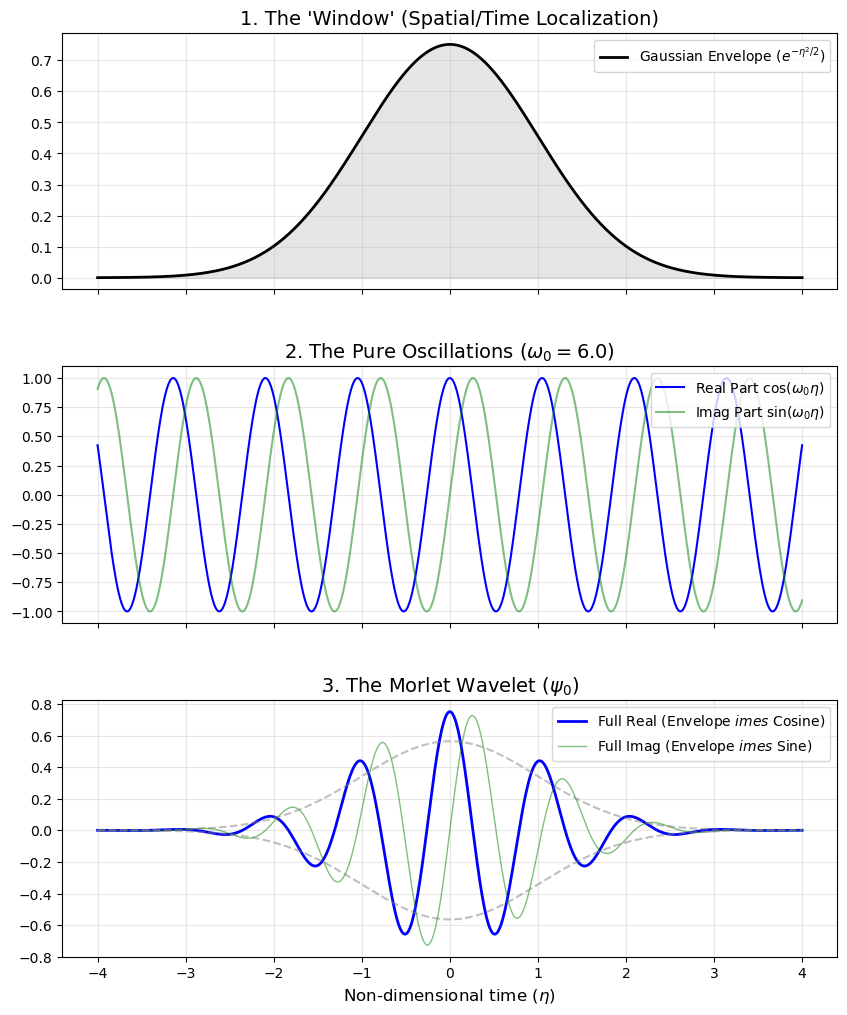

In [46]:
# Setup axis
eta = np.linspace(-4, 4, 1000)
w0 = 6.0
env, cos_part, sin_part, full = morlet_components(eta, w0)

# Create the multi-panel plot
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
plt.subplots_adjust(hspace=0.3)

# Panel 1: The Envelope
axes[0].plot(eta, env, color='black', lw=2, label=r'Gaussian Envelope ($e^{-\eta^2/2}$)')
axes[0].fill_between(eta, env, alpha=0.1, color='black')
axes[0].set_title("1. The 'Window' (Spatial/Time Localization)", fontsize=14)
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# Panel 2: The Pure Oscillations
axes[1].plot(eta, cos_part, color='blue', label=r'Real Part $\cos(\omega_0 \eta)$')
axes[1].plot(eta, sin_part, color='green', alpha=0.5, label=r'Imag Part $\sin(\omega_0 \eta)$')
axes[1].set_title(f"2. The Pure Oscillations ($\omega_0 = {w0}$)", fontsize=14)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

# Panel 3: The Combined Wavelet (The Mother)
axes[2].plot(eta, full.real, color='blue', lw=2, label='Full Real (Envelope $\times$ Cosine)')
axes[2].plot(eta, full.imag, color='green', lw=1, alpha=0.5, label='Full Imag (Envelope $\times$ Sine)')
axes[2].plot(eta, env * np.pi**(-0.25), '--', color='gray', alpha=0.5)
axes[2].plot(eta, -env * np.pi**(-0.25), '--', color='gray', alpha=0.5)
axes[2].set_title(r"3. The Morlet Wavelet ($\psi_0$)", fontsize=14)
axes[2].set_xlabel(r"Non-dimensional time ($\eta$)", fontsize=12)
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

plt.show()

We clearly see how the Guassian acts as an envelope for the osscilation and restricts the wave in space, unlike the Fourier transform that performs the convolution with an infinite cosine series.  In the FFT we introduced a window to taper the start and end of a series... the wavelet is simply taking this idea further and tapering the window to a smaller period and then "passing" this over the data. 

Let's examine the two key parameters now of the wavelet analysis. 

### key parameters 

So the key parameters are 

- $s$ the stretch factor, related to the (time)scale we are analysing.
- $\omega_0$ that sets the number of "wiggles" within the wave packet.

Let's see how this works... The following code plots the wavelet and you can define $\omega_0$ at the start.  A default value is 6, but you can set it to 2 or 10, or 20... 

#### EXERCISE: set $\omega_0$ (w0 in the code) to 2, 5, 10, 20 and discuss the implications.


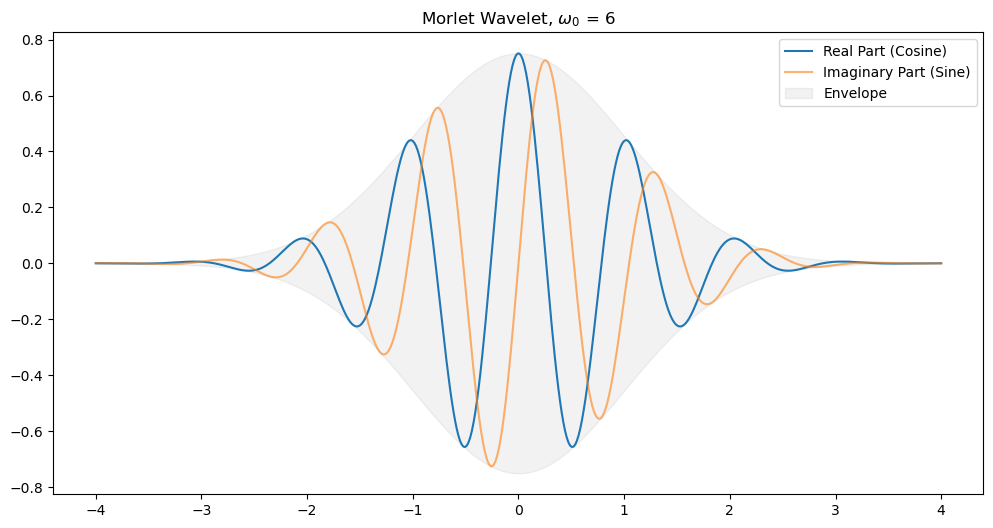

In [3]:
# Create a centered time axis
t_axis = np.linspace(-4, 4, 500)

w0=6
wavelet_vals = morlet_wavelet(t_axis, w0=w0)

plt.rcParams['figure.figsize'] = (12, 6)
plt.plot(t_axis, wavelet_vals.real, label="Real Part (Cosine)")
plt.plot(t_axis, wavelet_vals.imag, label="Imaginary Part (Sine)", alpha=0.6)
plt.title("Morlet Wavelet, $ \omega_0 $ = "+str(w0))
plt.fill_between(t_axis, np.abs(wavelet_vals), -np.abs(wavelet_vals), 
                 color='gray', alpha=0.1, label="Envelope")
plt.legend()
plt.show()

#### Why we set $\omega_0 = 6$:

There is a fundamental "Uncertainty Principle" in signal processing: You cannot have perfect resolution in both Time and Frequency.

- If $\omega_0$ is high (e.g., 20): You get amazing frequency resolution (you can tell the difference between a 10.1 and 10.2 "length" cycle), but the wavelet envelope is so "wide" relative to the oscillation length that you lose track of exactly when the cycle started or ended. Essentially it starts to look like a Fourier analysis...
  
- If $\omega_0$ is low (e.g., 2): You know exactly when a pulse happened, but you have no idea what its frequency was because there weren't enough wiggles to measure it well.  In addition, we need the cosine to have a rough zero mean and when $\omega_0$ is low this is usually not the case.

$\omega_0 = 6$ is the "Golden Middle." It provides just enough wiggles (about 3 visible oscillations) to give a very good estimate of the frequency, while remaining narrow enough in time to show you exactly when a climate event (like an El Niño) began.  In addition, once $\omega_0$ approaches 6 the residual is very, very close to zero. 

So the wavelength ($\lambda$); the distance between two peaks of the cosine wiggles is exactly $2\pi \frac{s}{\omega_0}$, in which case you might wonder why we don't set $\omega_0 = 2\pi$, which would mean the wavelength is exactly our stretching length scale $s$ (instead of $2\pi s / 6 \approx \mathbf{1.047} s$)

The reason is simply that 6 was adopted as a nearest convenient integer and thus is continued as standard to ensure all Wavelet results are consistent. 

## Deriving the Exact Morlet Wavelet (The Admissibility Correction)

To be mathematically admissible, a wavelet must have a mean of exactly zero. This means its integral across all time ($\eta$) must equal zero:

$$\int_{-\infty}^{\infty} \psi(\eta) d\eta = 0$$

Let's evaluate the integral of the simplified Morlet wavelet, $\psi_0(\eta) = \pi^{-1/4} e^{j \omega_0 \eta} e^{-\eta^2/2}$, to see if it meets this condition.

### Integrating the Simplified Wavelet

We want to find the mean, $M$, by integrating over all space:

$$M = \int_{-\infty}^{\infty} \pi^{-1/4} e^{j\omega_0 \eta} e^{-\eta^2/2} d\eta$$

To solve this, we can combine the exponents:

$$M = \pi^{-1/4} \int_{-\infty}^{\infty} e^{-\frac{1}{2}\eta^2 + j\omega_0 \eta} d\eta$$

Next, we complete the square in the exponent. We can rewrite $-\frac{1}{2}\eta^2 + j\omega_0 \eta$ as:

$$-\frac{1}{2} \left( \eta^2 - 2j\omega_0 \eta \right)$$
$$= -\frac{1}{2} \left( \eta^2 - 2j\omega_0 \eta + (j\omega_0)^2 - (j\omega_0)^2 \right)$$
$$= -\frac{1}{2} (\eta - j\omega_0)^2 - \frac{\omega_0^2}{2}$$

Substitute this back into the integral:

$$M = \pi^{-1/4} \int_{-\infty}^{\infty} e^{-\frac{1}{2}(\eta - j\omega_0)^2 - \frac{\omega_0^2}{2}} d\eta$$

We can pull the constant term out of the integral:

$$M = \pi^{-1/4} e^{-\omega_0^2/2} \int_{-\infty}^{\infty} e^{-\frac{1}{2}(\eta - j\omega_0)^2} d\eta$$

The remaining integral is simply a standard Gaussian integral shifted by a complex constant, which evaluates to $\sqrt{2\pi}$:

$$M = \pi^{-1/4} \sqrt{2\pi} e^{-\omega_0^2/2}$$

Because $M \neq 0$, the simplified Morlet wavelet violates the admissibility condition! 

### Deriving the Correction Factor

To force the mean to zero, we must introduce a constant correction term, $C$, inside the parent wavelet function:

$$\psi(\eta) = \pi^{-1/4} \left( e^{j\omega_0 \eta} - C \right) e^{-\eta^2/2}$$

For the total integral to be zero, the integral of our correction term must perfectly cancel out the mean $M$ we just calculated.

The integral of the correction term alone is:

$$\int_{-\infty}^{\infty} \pi^{-1/4} C e^{-\eta^2/2} d\eta = \pi^{-1/4} C \sqrt{2\pi}$$

(since we can move the C and $\pi$ term out of the integral and are left with the Gaussian again). Setting the correction integral equal to $M$:

$$\pi^{-1/4} C \sqrt{2\pi} = \pi^{-1/4} \sqrt{2\pi} e^{-\omega_0^2/2}$$

Canceling $\pi^{-1/4} \sqrt{2\pi}$ from both sides leaves us with the exact correction factor:

$$C = e^{-\omega_0^2/2}$$

### The Complete Morlet Wavelet

By plugging $C$ back into our corrected equation, we arrive at the exact, zero-mean mathematical definition of the complex Morlet wavelet:

$$\psi(\eta) = \pi^{-1/4} \left( e^{j\omega_0 \eta} - e^{-\omega_0^2/2} \right) e^{-\eta^2/2}$$

*(Note: In practice, when $\omega_0 \geq 5$, the term $e^{-\omega_0^2/2}$ is so infinitesimally small that it is neglected.*

## Scale of wiggles, the analysis timescale $\lambda$

To derive the lengthscale of the oscillations in the wavelet that define the scale we are analysign for a given $\omega_0$ and $s$, we need to take the Fourier transform of the **full** Morlet wavelet and then differentiate that with respect to $s$ to find out at which scale it maximises...  For the moment we will skip the math (DERIVATION TO BE ADDED LATER HERE), and just give the result:

$$\lambda_f = \frac{4\pi s}{\omega_0 + \sqrt{2 + \omega_0^2}}$$

Again for reasonably large values of $\omega_0$ (where we anyway neglect the correction) then $\omega_0 + \sqrt{2 + \omega_0^2} \approx 2 \omega_0$ and the lengthscale simplifies to 

$$\lambda_f \approx \frac{2\pi s}{\omega_0}$$

(Which I believe is often coded from scratch in some packages).

In climate science and geophysics, we want the **Scale** to be intuitively equal to the **Period** so we don't need a calculator to read our own graphs. 

- If we choose $\omega_0 = 6$, $\lambda \approx 1.03 \times s$
- This means a feature at **Scale 10** is almost exactly a **10-unit cycle** (e.g., 10 years if data points are annual).

Remember, we could have set $\omega_0 = 2 \pi$ and then $s\approx \lambda$, nice, but no one does it so why start a new trend?  

**Summary:** 

$\omega_0$ is the **internal geometry** of your "packet", and $s$ is the **physical size** you stretch that "packet" to. By picking $\omega_0=6$, you ensure your "Wavelet Ruler" uses the same units as a "Fourier Ruler."

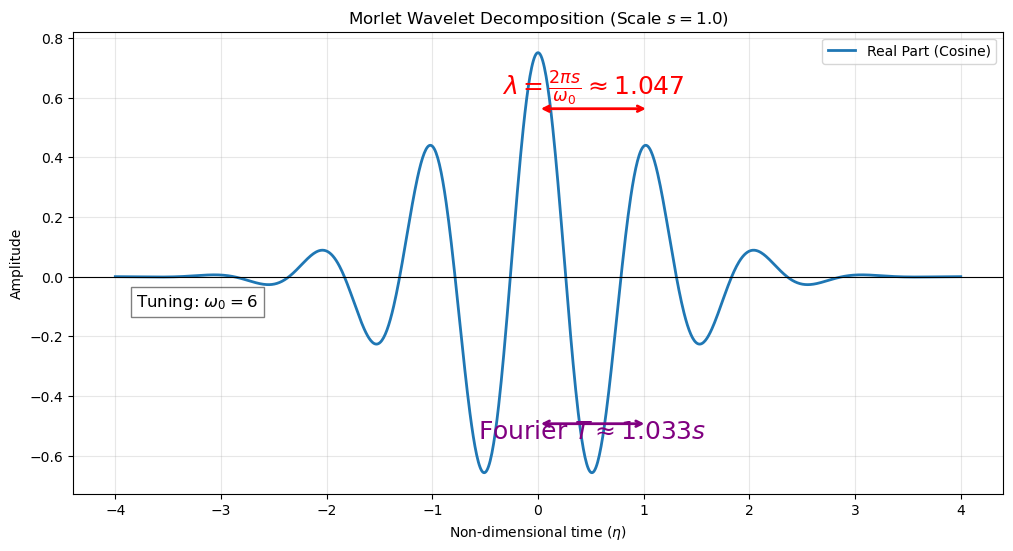

In [70]:
# Parameters
w0 = 6 #2*np.pi  # frequency
s = 1.0       # Scale for the mother wavelet

# include s in the axis range 
t_axis = np.linspace(-4*s, 4*s, 1000)

# To keep the energy consistent (so the amplitude doesn't drop), 
# multiply by the normalization factor:
wavelet_vals = (1/np.sqrt(s)) * morlet_wavelet(t_axis / s, w0=w0)

# 2. Dynamic math for labels

# this is the approximation for when w0>=5
wavelength = (2 * np.pi * s) / w0

# this is the exact that is derived from the Fourier transform of the full CWT 
# with the CORRECTION factor using Morlet. I need to add this derivation to the notes
fourier_period = s * (4 * np.pi) / (w0 + np.sqrt(2 + w0**2))

plt.figure(figsize=(12, 6))
plt.plot(t_axis, wavelet_vals.real, label="Real Part (Cosine)", lw=2)

yarrow1=np.max(wavelet_vals.real)*0.75
yarrow2=np.min(wavelet_vals.real)*0.75

# --- THE DYNAMIC ANNOTATION ---
# Arrow starts at the central peak (0) and ends at the next peak to the right
plt.annotate('', xy=(wavelength, yarrow1), xytext=(0, yarrow1), 
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))

# Label using LaTeX string formatting
label_text = r"$\lambda = \frac{2\pi s}{\omega_0} \approx " + f"{wavelength:.3f}$"
plt.text(wavelength/2, yarrow1+0.05, label_text, color='red', ha='center', fontsize=18, fontweight='bold')

# Horizontal line for w0 visualization
plt.axhline(0, color='black', lw=0.8)
plt.text(-3.8, -0.1, r"Tuning: $\omega_0 = " + f"{w0}$", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Add the Fourier Period info for comparison
# Arrow starts at the central peak (0) and ends at the next peak to the right
plt.annotate('', xy=(fourier_period, yarrow2), xytext=(0, yarrow2), 
             arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
plt.text(fourier_period/2, yarrow2-0.05, r"Fourier $T \approx " + f"{fourier_period:.3f}s$", ha='center', color='purple', fontsize=18)

plt.title(f"Morlet Wavelet Decomposition (Scale $s={s}$)")
plt.xlabel(r"Non-dimensional time ($\eta$)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Wavelet analysis from scratch

As you know, I like to code things up from scratch, so let's give it a go - 

In [71]:
def cwt_scratch(data, dt, scales, w0=6.0):
    n_signal = len(data)
    cwt_matrix = np.zeros((len(scales), n_signal), dtype=complex)
    
    for i, s in enumerate(scales):
        
        # 1. Create wavelet time vector
        
        # this is the width in standard deviations:
        # a half width of 3*s cutting the wavelet off while it 
        # still has 1% of its power. 
        # This creates "edge effects" or "ringing" in your transform 
        # because you've abruptly chopped off the ends of the wave.
        # at 8*s we have $e^{-0.5(8^2)} = 
        # e^{-32} \approx 1.2 \times 10^{-14}$ amplitude
        half_width = 8 * s
        n_samples = int(2 * half_width / dt)
        # ensure we have central pt by making the len odd.
        if n_samples % 2 == 0: n_samples += 1 
        t_wavelet = np.linspace(-half_width, half_width, n_samples)
        
        # Generate wavelet using our earlier routine, yay!!! 
        wavelet = morlet_wavelet(t_wavelet / s, w0) * (1 / np.sqrt(s))
        
        # Perform convolution, let's use numpy for this as we already saw this earlier 
        # but if you want you can use the dot product we introduced in the DFT lecture
        # if you really really want to :-) 
        full_conv = np.convolve(data, np.conj(wavelet), mode='full') * dt
        
        # Manually slice the center to match n_signal
        # 
        start = (len(wavelet) - 1) // 2
        end = start + n_signal
        cwt_matrix[i, :] = full_conv[start:end]
        
    return cwt_matrix
    
 

Let's look at how the code processes a wave with a 30-day period (s = 30), assuming dt = 0.0416 (1 hour):

- half_width = $8 * s$

The code calculates that the wavelet needs a half-width of $8 \times 30 = 240$ days.

- n_samples = int(2 * half_width / dt) 

takes the total physical width (480 days) and divides it by your time step (0.0416 days per sample). The function dynamically realizes it needs to build an array of 11,538 data points to accurately draw a 30-day wave using hourly data.

- t_wavelet = np.linspace(-half_width, half_width, n_samples)

generates an incredibly high-resolution time vector spanning exactly from -240 days to +240 days.

- t_wavelet / s

divide days by days. The units cancel out entirely, leaving a dimensionless array to feed into the Morlet routine.

Ok, are we ready to give this a go...

## 2. Toy Example: Non-Stationary Sine Waves

Before tackling messy climate data, let's prove our code works. We will create a signal that is non-stationary: 
1. For the first 500 time steps, it has a period of 20 (high frequency).
2. For the last 500 time steps, it has a period of 80 (low frequency).

A traditional Fourier transform would just show peaks at 20 and 80, giving no information about *when* those frequencies occurred. Let's see what our wavelet scalogram does.

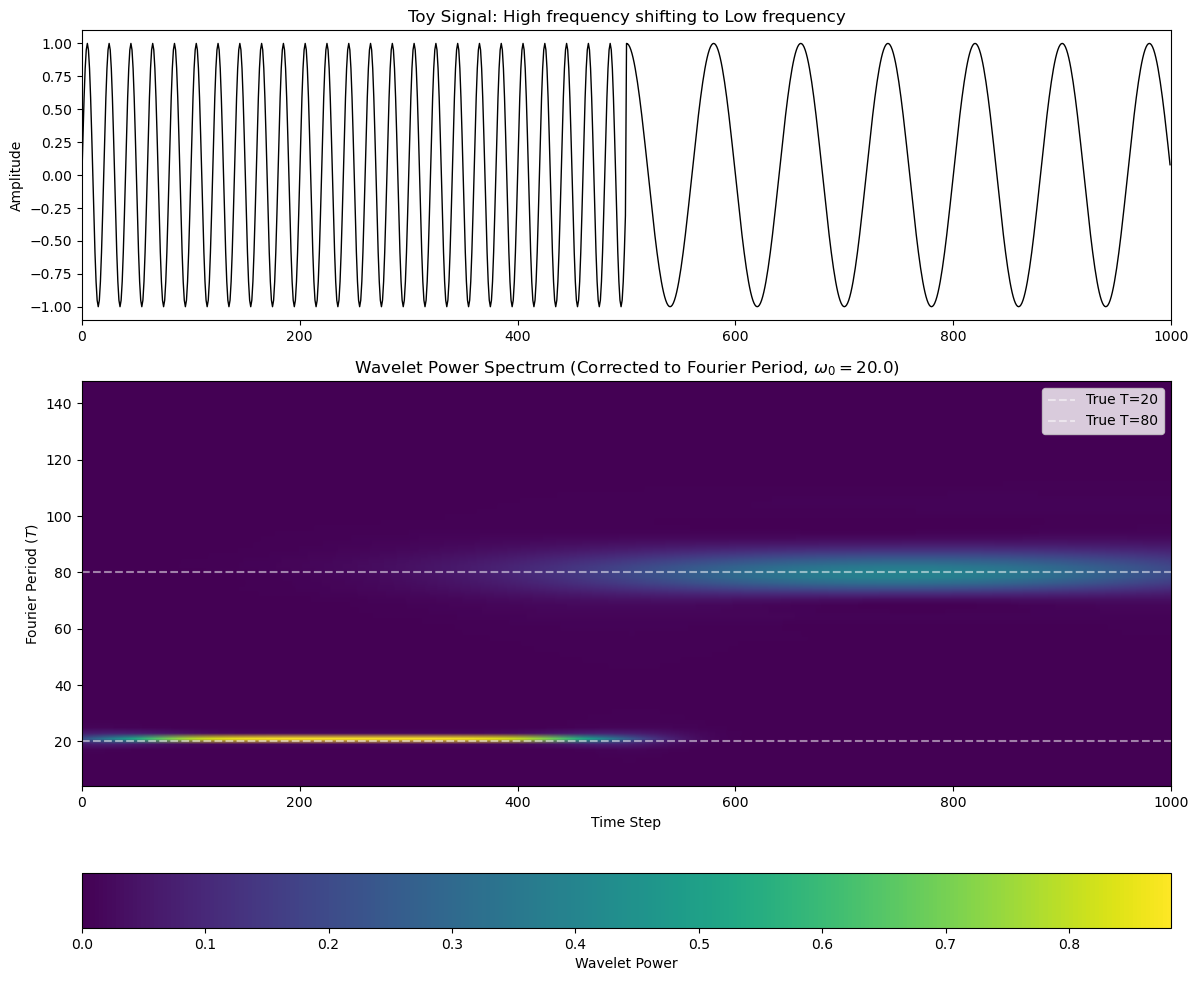

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# omega_0 - DEFAULT value is 6. 
w0 = 20.0

# toy data, two sinewaves of 20 and 80...
npt = 1000
t_toy = np.arange(npt)
signal = np.zeros(npt)
mid = npt // 2 
signal[:mid] = np.sin(2 * np.pi * t_toy[:mid] / 20)  # Period = 20
signal[mid:] = np.sin(2 * np.pi * t_toy[mid:] / 80)  # Period = 80

# Cwt calc next

# Periods to analyse - 1,150 means we go from 1 to 150 days.
periods_toy = np.arange(4, 150, 2)

# Calculate the factor based on the current w0
# here use the full version but to be honest for w0>5 we could approx to 2pi/w0
fourier_factor = (4 * np.pi) / (w0 + np.sqrt(2 + w0**2))

# calc the scales needed to achieve those periods
# Since Period = Scale * Factor, then Scale = Period / Factor
scales_toy = periods_toy / fourier_factor

# CWT with these dynamically calculated scales
cwt_toy = cwt_scratch(signal, dt=1.0, scales=scales_toy, w0=w0)

# get the power, oh yes!
power_toy = np.abs(cwt_toy)**2

# We divide by 'scales' because Power (amplitude squared) 
# needs an s^1 correction to offset the sqrt(s) used in the CWT.
#for i in range(len(scales_toy)):
    power_toy[i, :] = power_toy[i, :] / scales_toy[i]
    
# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 2]})

# Top Panel: Signal
ax1.plot(t_toy, signal, color='black', lw=1)
ax1.set_title('Toy Signal: High frequency shifting to Low frequency')
ax1.set_ylabel('Amplitude')
ax1.set_xlim(0, npt)

# Bottom Panel: Scalogram (using Periods instead of raw scales)
im = ax2.imshow(power_toy, 
                extent=[0, npt, periods_toy[0], periods_toy[-1]], 
                aspect='auto', cmap='viridis', interpolation='bilinear',
                origin='lower') # origin='lower' keeps periods increasing upwards

ax2.set_title(f'Wavelet Power Spectrum (Corrected to Fourier Period, $\omega_0={w0}$)')
ax2.set_ylabel('Fourier Period ($T$)')
ax2.set_xlabel('Time Step')

# Add indicator lines for the true periods (20 and 80)
ax2.axhline(20, color='white', linestyle='--', alpha=0.5, label='True T=20')
ax2.axhline(80, color='white', linestyle='--', alpha=0.5, label='True T=80')
ax2.legend()

fig.colorbar(im, ax=ax2, orientation='horizontal', label='Wavelet Power', pad=0.15)

plt.tight_layout()
plt.show()

Notice how clearly the scalogram identifies both the exact period of the waves and the exact time step (500) where the regime shifts!

### QUESTION?
What do you  notice about the relative powers for the 20 and 80 step cycles?

In Wavelet analysis, there are two common ways to normalize, energy conserving or peak amplitude conserving. 

$L^2$ Normalization ("L" for Lebesgue). 

The $2$ refers to the exponent used in the integration. For a wavelet $\psi$, we ensure:$$\|\psi\|_2 = \sqrt{\int_{-\infty}^{\infty} |\psi(t)|^2 dt} = 1$$

The square means we are representing energy and this leads to the $1/\sqrt{s}$ scale factor,  which is what we use and is usually the default in wavelet analysis.  Go back to teh scratch cwt routine and find the line where we scale by $1/\sqrt(s)$, which ensures the wavelet has the same **total energy** at every scale. However, because the larger scales ($T=80$) are "stretched out" in time, they have more "samples" for a fixed sample rate. This makes larger scales appear to have higher power than smaller scales for the same input amplitude.

$L^1$ Normalization ($1/s$)

$$\|\psi\|_1 = \int_{-\infty}^{\infty} |\psi(t)| dt = 1$$

This ensures the peak amplitude is preserved across scales. If you use a scale factor $1/s$, a sine wave with amplitude 1.0 will result in a wavelet coefficient of roughly 1.0 at its corresponding scale, regardless of whether the period is 20 or 80... BUT...

In geophysics we want the "Total Energy" in the time domain to equal the "Total Energy" in the wavelet domain.  A consequence of this is that **White Noise** is "Flat" in $L^2$T his is the most practical reason for researchers. If you run a CWT on pure White Noise:With $1/\sqrt{s}$ ($L^2$): The average power will look roughly the same at all scales. The scalogram looks like a uniform "static."With $1/s$ ($L^1$): The high frequencies (small scales) will look much "louder" than the low frequencies.Since many scientists use wavelets to find signals buried in noise, they prefer a convention where the noise floor looks flat.

### Exercises 

1. try changing $\omega_0$
2. try setting the scale factor to L1 normalization

## 3. Application: African Easterly Waves in ERA5 Data

Now we apply this to a real meteorological phenomenon. African Easterly Waves (AEWs) are westward-propagating synoptic disturbances that originate over North Africa. They are primary precursors to Atlantic tropical cyclones.

AEWs are best detected in the meridional (v-component) wind at the 700 hPa level, typically exhibiting periods of **3 to 5 days**. Because they rely on the African Easterly Jet, they are highly seasonal, peaking during the summer monsoon (July to September).

We will load ERA5 reanalysis data. *(Note: For this notebook to run cleanly out-of-the-box, we generate a synthetic `xarray.DataArray` that mimics the structure and statistical properties of an ERA5 V-wind slice at 15°N, 0°E over a full year).* Let's use our CWT to detect the summer AEW activity.

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import requests
import io

# --- 1. FETCH AND LOAD THE NETCDF FILE FROM URL ---
url = "http://clima-dods.ictp.it/Users/tompkins/diploma/data/vwind_anom_detrend.nc"
print("Downloading NetCDF into memory...")
response = requests.get(url)
response.raise_for_status()

# Wrap bytes in BytesIO and read with scipy engine
#ds_real = xr.open_dataset(io.BytesIO(response.content), engine='scipy')
ds_real = xr.open_dataset(io.BytesIO(response.content), engine='h5netcdf')

# --- 2. EXTRACT 1D TIME SERIES ---
var_name = list(ds_real.data_vars)[0]  # Dynamically grab the main variable
# .squeeze() drops lon, lat, and pressure_level since they are length 1
da_vwind = ds_real[var_name].squeeze() 

In [63]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

def plot_wavelet_spectrum(time, periods, power, title="Wavelet Power Spectrum", 
                          v_signal=None, ylabel="Period (Days)"):
    """
    Plots a professional scalogram for atmospheric signals.
    Returns: (fig, ax_signal, ax_wavelet)
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [1, 2]})

    # 1. Top Panel: Time Series
    if v_signal is not None:
        ax1.plot(time, v_signal, color='black', lw=0.8)
        ax1.set_ylabel('Signal Amplitude')
        ax1.set_title('Input Time Series')
    ax1.grid(alpha=0.3)
    
    # --- INTERNAL POWER CALCULATION ---
    # Safely calculate variance normalization and log if v_signal is provided
    if v_signal is not None:
        variance = np.var(v_signal)
        norm_power = power / variance
    else:
        norm_power = power
        
    log_power = np.log2(norm_power + 1e-5)
    
    # Dynamically find the real ceiling of your data
    actual_max = np.nanmax(log_power)
    
    # Set the floor to the 50th percentile to hide background static
    # (Adjust this number up if it's still too noisy, down if it's too dark)
    actual_min = np.nanpercentile(log_power, 50) 
    
    # 2. Bottom Panel: The Scalogram
    pcm = ax2.pcolormesh(time, periods, log_power, 
                         shading='auto', 
                         vmin=actual_min,  # dynamically set!
                         vmax=actual_max,  # dynamically set! 
                         cmap='magma')

    # Standard atmospheric science log-y setup
    ax2.set_yscale('log')
    # Custom ticks for diurnal and AEW ranges
    ytick_values = [0.5, 1, 2, 3, 4, 5, 7, 10, 15, 30]
    ax2.set_yticks([t for t in ytick_values if t >= periods.min() and t <= periods.max()])
    ax2.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    
    # Utilizing your custom ylabel argument
    ax2.set_ylabel(ylabel)
    ax2.set_title(title)

    # Format X-Axis
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    # Colorbar
    fig.colorbar(pcm, ax=ax2, orientation='horizontal', pad=0.15, label='log2(Power / Variance)')

    return fig, ax1, ax2

Detected time step (dt): 0.0417 days
Computing CWT...


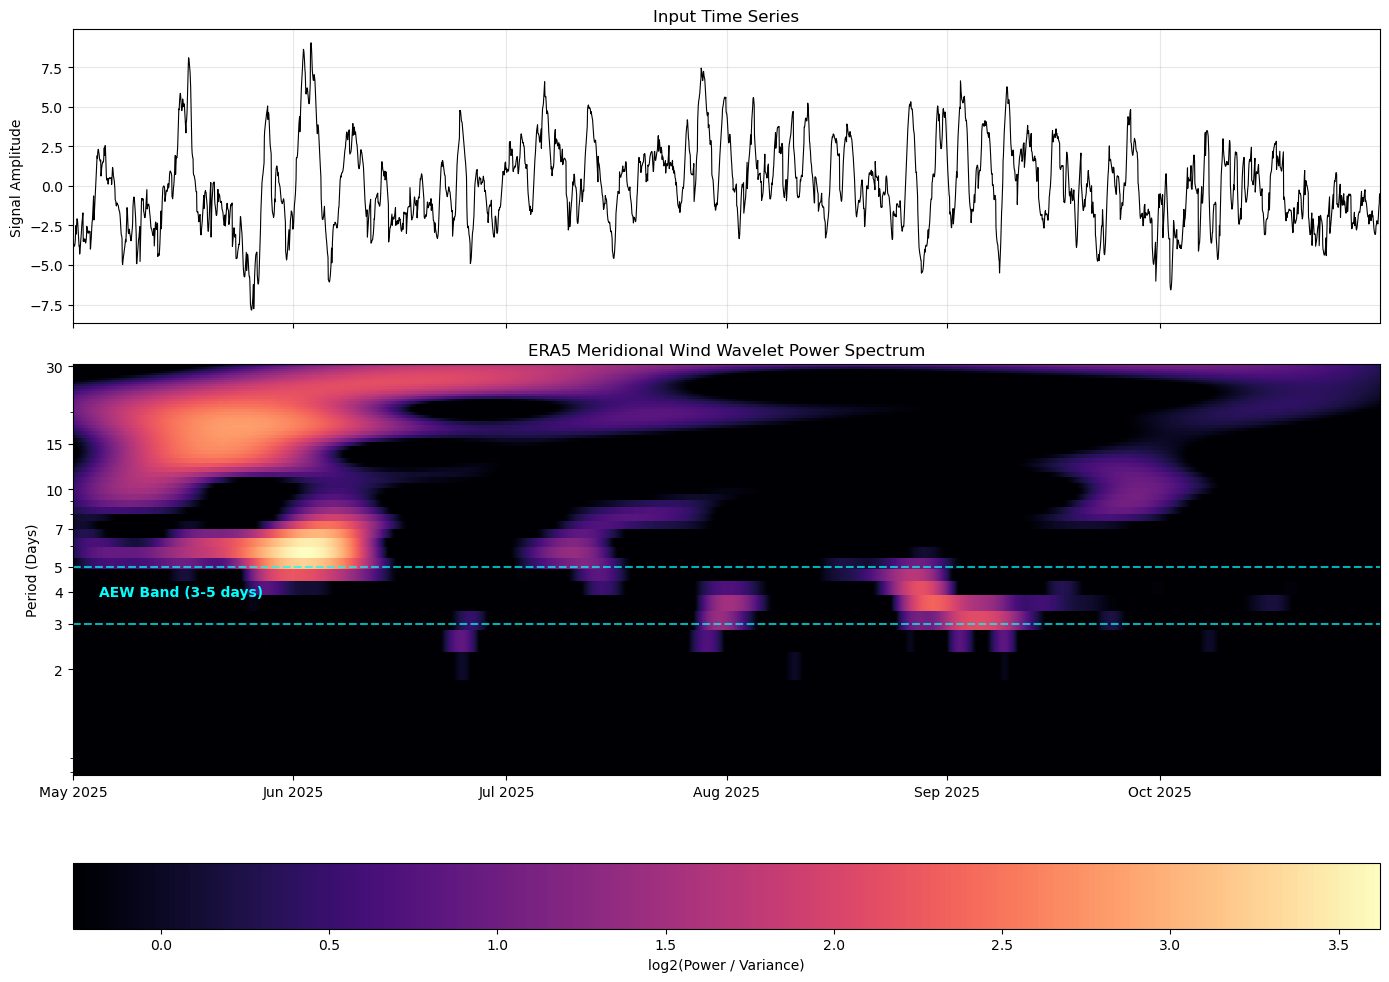

In [64]:
# Grab the 1D arrays for the CWT (using your specific 'valid_time' dimension)
time_era5 = da_vwind['valid_time'].values
v_wind_data = da_vwind.values

# --- DYNAMIC 'dt' CALCULATION ---
# Subtracting two datetime64 objects gives a timedelta64.
# Dividing by timedelta64(1, 'D') converts that exact duration into a fraction of a day.
dt_days = float((time_era5[1] - time_era5[0]) / np.timedelta64(1, 'D'))
print(f"Detected time step (dt): {dt_days:.4f} days")

# --- PERFORM WAVELET ANALYSIS ---
print("Computing CWT...")
scales_era5 = np.arange(1, 30, 0.5)  

w0 = 6.0  # Default Morlet parameter

# Compute CWT using the dynamic dt
cwt_era5 = cwt_scratch(v_wind_data, dt=dt_days, scales=scales_era5, w0=w0)
power_era5 = np.abs(cwt_era5)**2

# --- CONVERT SCALES TO FOURIER PERIODS ---
# Your plotting function expects 'periods', not raw scales
fourier_factor = (4 * np.pi) / (w0 + np.sqrt(2 + w0**2))
periods_era5 = scales_era5 * fourier_factor

# --- 4. PLOT ---
# Call your new professional plotting function!
fig, ax_sig, ax_wav = plot_wavelet_spectrum(
    time=time_era5, 
    periods=periods_era5, 
    power=power_era5, 
    title="ERA5 Meridional Wind Wavelet Power Spectrum", 
    v_signal=v_wind_data, 
    ylabel="Period (Days)"
)

# You can still add your AEW band highlights to the returned ax_wav object!
ax_wav.axhline(y=3, color='cyan', linestyle='--', alpha=0.7, lw=1.5)
ax_wav.axhline(y=5, color='cyan', linestyle='--', alpha=0.7, lw=1.5)

# Place text dynamically based on the time array
ax_wav.text(time_era5[int(len(time_era5)*0.02)], 4, 'AEW Band (3-5 days)', 
            color='cyan', fontweight='bold', verticalalignment='center')

plt.tight_layout()
plt.show()

## 4. Transitioning to Standard Packages (`PyWavelets`)

While writing the code from scratch demystifies the mathematics, doing this operation manually using standard convolution is slow for large datasets (like 40 years of daily global gridded data). 

Professional packages utilize the **Fast Fourier Transform (FFT)** to compute the convolution theorem rapidly in frequency space. They also properly handle zero-padding at the boundaries to prevent circular convolution wrap-around.

Here, we implement the exact same analysis using `PyWavelets` (`pywt`).

In [40]:
# In PyWavelets, the complex Morlet is 'cmorB-C', where B is bandwidth and C is center frequency.
# To match our analytical w0=6, we use a center frequency of ~0.955 (since pywt defines it as w0/(2*pi))
wavelet_pkg = 'cmor1.0-0.955'

# pywt.cwt returns the coefficients and the corresponding frequencies
#cwt_pkg, freqs_pkg = pywt.cwt(da_vwind.values, scales_era5, wavelet_pkg, sampling_period=dt_days)
#power_pkg = np.abs(cwt_pkg)**2

# note!!!! 
# Create 80 logarithmically spaced scales.
# 1 day = 24 hours, 30 days = 720 hours. 
scales_pkg = np.geomspace(24, 720, num=80)

# Pass your dynamic dt_days here!
cwt_pkg, freqs_pkg = pywt.cwt(v_wind_data, scales_pkg, wavelet_pkg, sampling_period=dt_days)
power_pkg = np.abs(cwt_pkg)**2

# Compare the two arrays to prove they are computing the same thing
# Find the maximum power to understand the scale
max_power = np.nanmax(power_era5)

# Calculate the difference as a percentage of the peak signal
relative_diff = (diff / max_power) * 100

print(f"Max Bespoke Power: {max_power:.2f}")
print(f"Mean Absolute Diff: {diff:.2f}")
print(f"Relative Difference: {relative_diff:.2f}%")


Max Bespoke Power: 84.57
Mean Absolute Diff: 8.16
Relative Difference: 9.64%


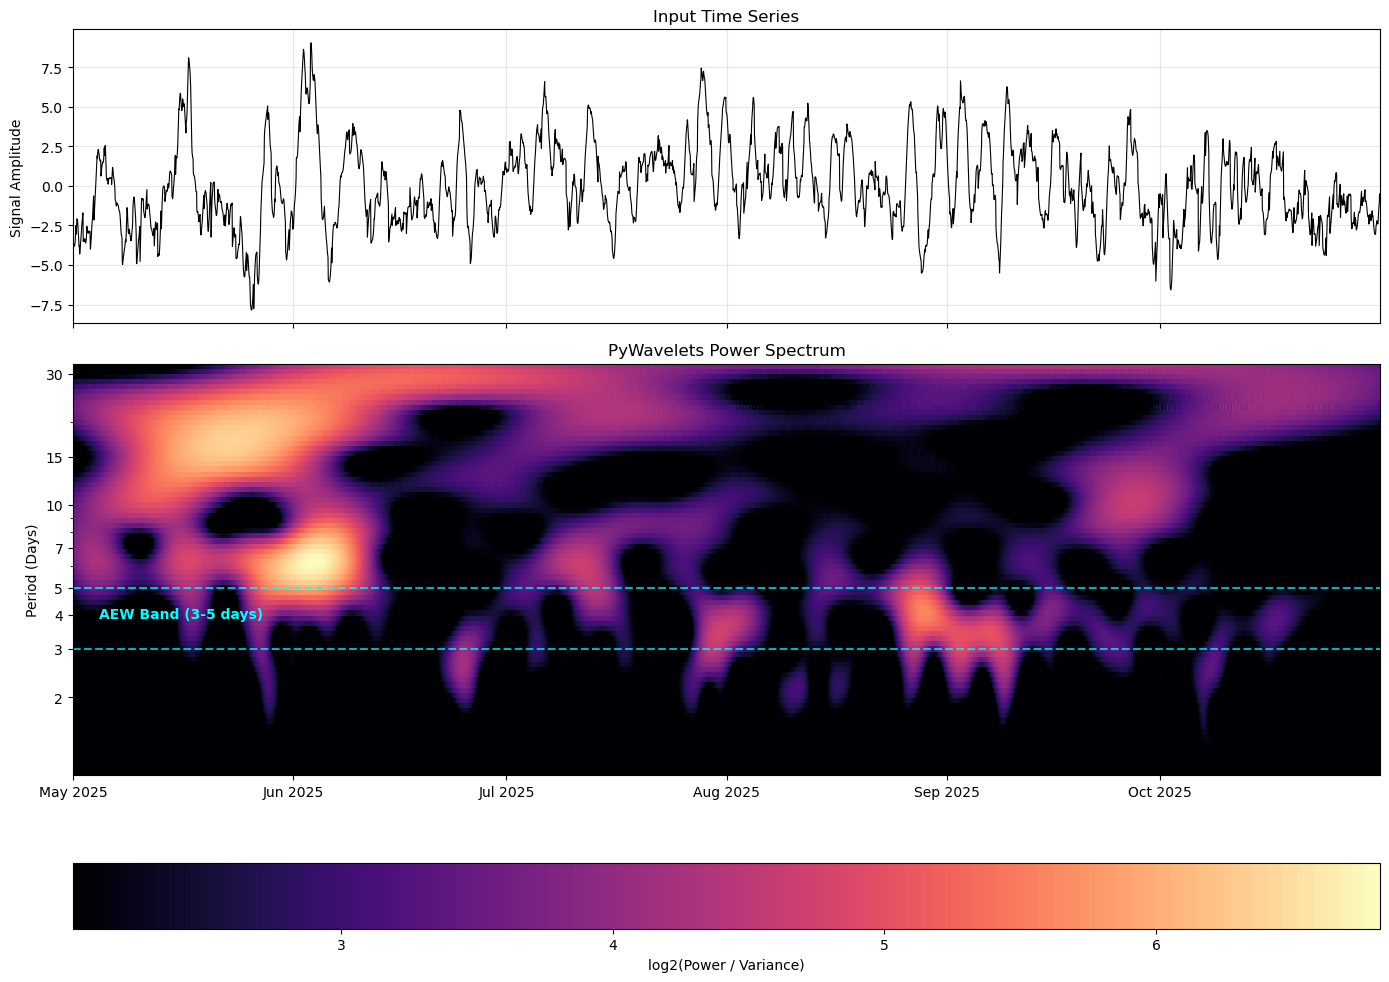

In [41]:
# --- CONVERT FREQUENCY TO PERIOD ---
# PyWavelets returns cycles per time-unit. Since dt is in days, 1/f is days.
periods_pkg = 1.0 / freqs_pkg

# --- PLOT USING YOUR ROBUST FUNCTION ---
fig_pkg, ax_sig_pkg, ax_wav_pkg = plot_wavelet_spectrum(
    time=time_era5, 
    periods=periods_pkg, 
    power=power_pkg, 
    title="PyWavelets Power Spectrum", 
    v_signal=v_wind_data, 
    ylabel="Period (Days)"
)

# Add your AEW band highlights
ax_wav_pkg.axhline(y=3, color='cyan', linestyle='--', alpha=0.7, lw=1.5)
ax_wav_pkg.axhline(y=5, color='cyan', linestyle='--', alpha=0.7, lw=1.5)
ax_wav_pkg.text(time_era5[int(len(time_era5)*0.02)], 4, 'AEW Band (3-5 days)', 
            color='cyan', fontweight='bold', verticalalignment='center')

plt.tight_layout()
plt.show()

## The Cone of Influence (COI)

If you look closely at the edges of our previous scalograms, you might notice the power drops off or behaves strangely. This introduces a critical concept in wavelet analysis: **The Cone of Influence (COI)**.

Because the wavelet is computed using a convolution, it requires data on both sides of a given time step. As we approach the beginning or end of our time series, the scaled wavelet extends beyond the bounds of our actual data. 

To compute the transform at the edges, algorithms implicitly pad the data (usually with zeros). This zero-padding reduces the variance at the edges, creating artificially low wavelet power. 

The COI defines the region of the wavelet spectrum where these edge effects become significant. It is mathematically defined as the e-folding time of the autocorrelation of the wavelet power. For a Morlet wavelet with $\omega_0 = 6$, the e-folding time is roughly:

$$ t_{COI} = \sqrt{2} s $$

Where $s$ is the wavelet scale. Because lower frequencies (larger scales) use wider wavelets, the edge effects penetrate deeper into the time series. This creates a cone-shaped region at the boundaries. Any wavelet power outside the COI (often shaded out) should be interpreted with high skepticism.

Here is a calculation of the COI which is then overplotted over the data. 

In [43]:
import matplotlib.dates as mdates
import numpy as np

def add_coi(ax, time, periods, w0=6.0):
    """
    Overlays the Cone of Influence (COI) onto an existing wavelet axis.
    Shades out the regions influenced by edge effects.
    """
    # 1. Convert datetime objects to numerical days so we can add/subtract t_coi
    t_num = mdates.date2num(time)
    t0, t1 = t_num[0], t_num[-1]
    
    # 2. Convert Fourier Period back to wavelet scale (s)
    # For Morlet w0=6, the relationship is Period ≈ 1.036 * s
    fourier_factor = (4 * np.pi) / (w0 + np.sqrt(2 + w0**2))
    scales = periods / fourier_factor
    
    # 3. Calculate the e-folding time (COI boundary) in physical days
    # As per your text: t_coi = sqrt(2) * s
    t_coi = np.sqrt(2) * scales
    
    # 4. Define the left and right boundary curves
    coi_left = t0 + t_coi
    coi_right = t1 - t_coi
    
    # 5. Shade the regions outside the COI
    # We use 'fill_betweenx' to fill from the edges inward
    ax.fill_betweenx(periods, t0, coi_left, color='white', alpha=0.4, 
                     hatch='//', edgecolor='black', zorder=5)
    ax.fill_betweenx(periods, coi_right, t1, color='white', alpha=0.4, 
                     hatch='//', edgecolor='black', zorder=5)
    
    # 6. Draw the definitive boundary line
    ax.plot(coi_left, periods, 'k--', lw=1.5, alpha=0.8, zorder=6)
    ax.plot(coi_right, periods, 'k--', lw=1.5, alpha=0.8, zorder=6)
    
    # Reset x-limits just in case the fill stretched the plot bounds
    ax.set_xlim(t0, t1)

let's try it out. 

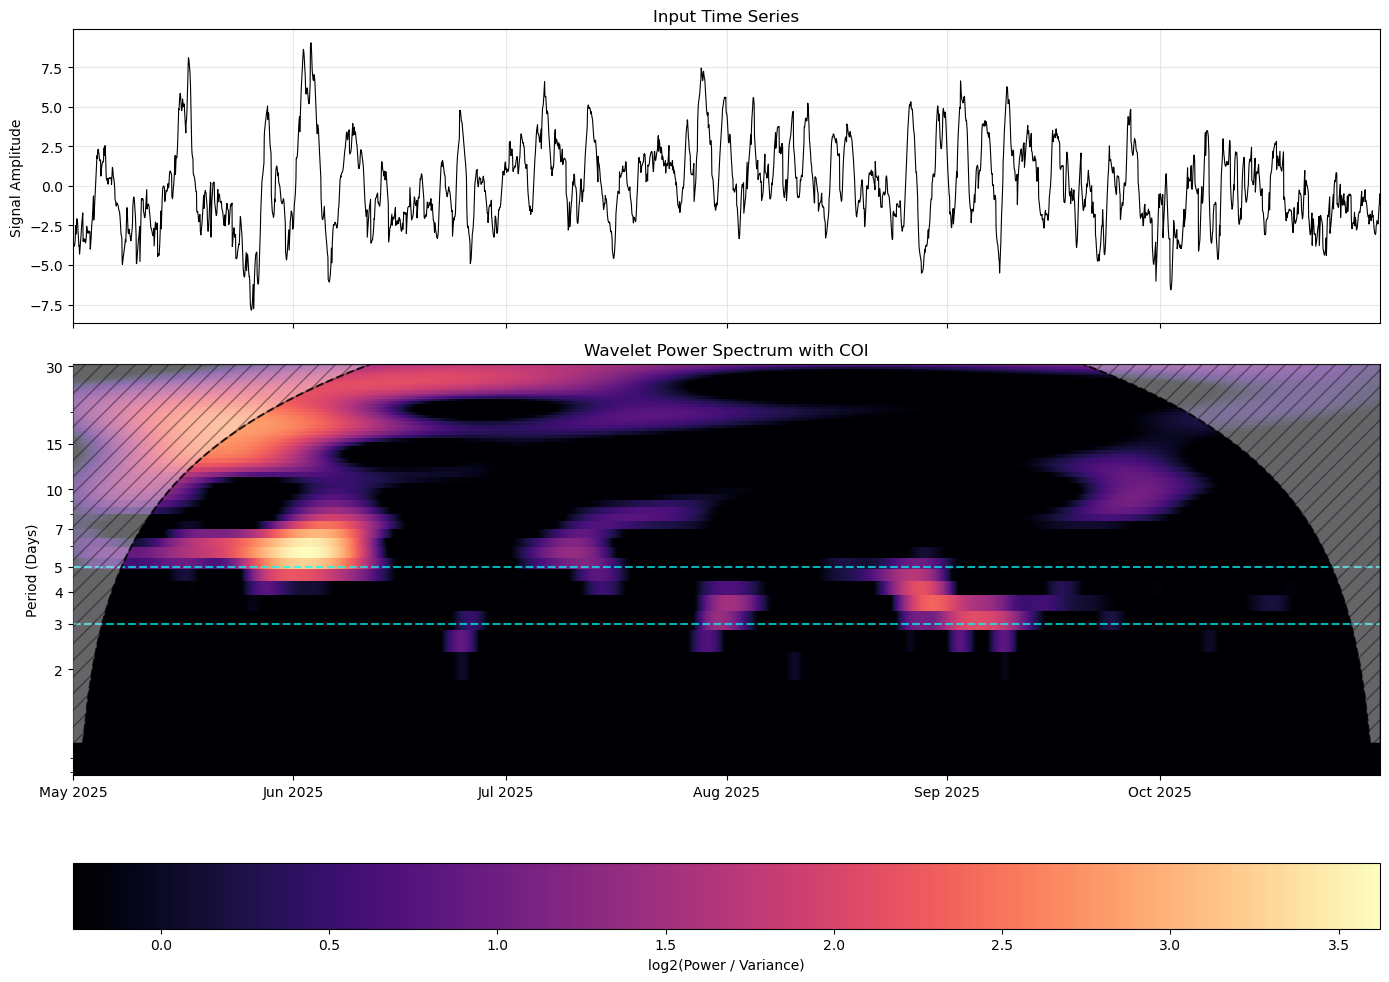

In [44]:
# 1. Plot your wavelet (using either bespoke or PyWavelets)
fig, ax_sig, ax_wav = plot_wavelet_spectrum(
    time=time_era5, 
    periods=periods_era5, # or periods_pkg
    power=power_era5,     # or power_pkg
    title="Wavelet Power Spectrum with COI", 
    v_signal=v_wind_data, 
    ylabel="Period (Days)"
)

# 2. Add your AEW band highlights
ax_wav.axhline(y=3, color='cyan', linestyle='--', alpha=0.7, lw=1.5)
ax_wav.axhline(y=5, color='cyan', linestyle='--', alpha=0.7, lw=1.5)

# 3. Add the Cone of Influence!
add_coi(ax=ax_wav, time=time_era5, periods=periods_era5)

plt.tight_layout()
plt.show()

## Exercise ideas...  

1. Try to download V-winds for other years from ERA5 and see how much variation there is from year to year in winds...
2. Here we used 8N-12N and 8E-12E means...  what about trying another box further north
3. Think of a wave or osscilation you have learned about in your courses.  It could be equatorial Rossby waves, or the Madden Julian oscillation - can you think of a variable you can analyse to see if you can see periods when the wave is active or not?


### Further Reading:

Pywavelets documentation and examples: 
https://pywavelets.readthedocs.io/en/latest/ref/cwt.html

Torrence, Christopher, and Gilbert P. Compo. "A practical guide to wavelet analysis." Bulletin of the American Meteorological society 79.1 (1998): 61-78.
https://journals.ametsoc.org/view/journals/bams/79/1/1520-0477_1998_079_0061_apgtwa_2_0_co_2.xml